In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('mortality_missing_values.csv')
df2 = pd.read_csv('president_polls_2016.csv')

In [3]:
df

,Year,AgeGroup,DeathRate
0,1900.0,01-04 Years,1983.8
1,NaN,01-04 Years,1695.0
2,1902.0,01-04 Years,NaN
3,1903.0,01-04 Years,1542.1
4,NaN,01-04 Years,NaN
...,...,...,...
471,2014.0,15-19 Years,45.5
472,2015.0,15-19 Years,48.3
473,2016.0,15-19 Years,51.2
474,2017.0,15-19 Years,51.5


In [4]:
df.head(10)

,Year,AgeGroup,DeathRate
0,1900.0,01-04 Years,1983.8
1,NaN,01-04 Years,1695.0
2,1902.0,01-04 Years,NaN
3,1903.0,01-04 Years,1542.1
4,NaN,01-04 Years,NaN
5,1905.0,01-04 Years,1498.9
6,NaN,01-04 Years,NaN
7,1907.0,01-04 Years,NaN
8,1908.0,01-04 Years,1396.8
9,1909.0,01-04 Years,1348.9


In [5]:
df.tail(10)

,Year,AgeGroup,DeathRate
466,2009.0,15-19 Years,51.9
467,2010.0,15-19 Years,49.4
468,2011.0,15-19 Years,48.9
469,2012.0,15-19 Years,47.2
470,2013.0,15-19 Years,44.8
471,2014.0,15-19 Years,45.5
472,2015.0,15-19 Years,48.3
473,2016.0,15-19 Years,51.2
474,2017.0,15-19 Years,51.5
475,2018.0,15-19 Years,49.2


In [6]:
df.isna().any()

Year          True
AgeGroup     False
DeathRate     True
dtype: bool

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 476 entries, 0 to 475
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Year       473 non-null    float64
 1   AgeGroup   476 non-null    object 
 2   DeathRate  472 non-null    float64
dtypes: float64(2), object(1)
memory usage: 11.3+ KB


In [8]:
df.nunique()

Year         119
AgeGroup       4
DeathRate    426
dtype: int64

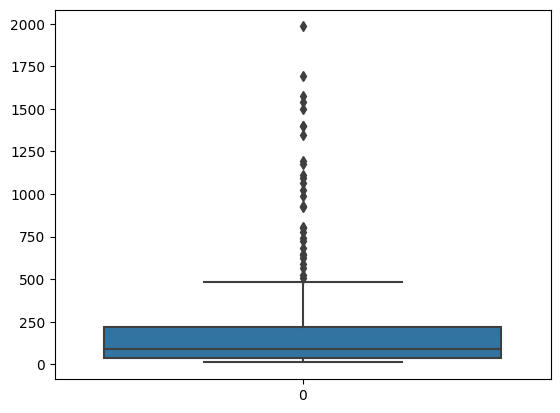

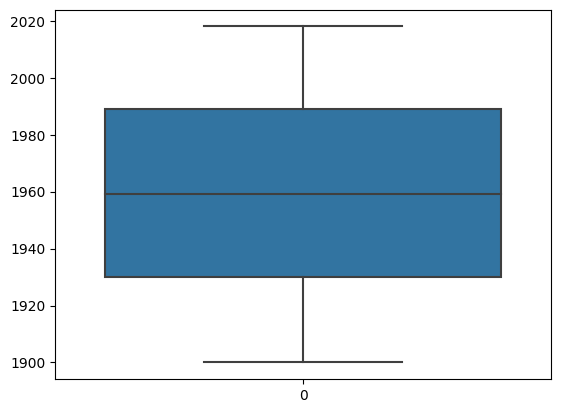

In [9]:
sns.boxplot(df['DeathRate'])
plt.show()
sns.boxplot(df['Year'])
plt.show()

In [10]:
df2.columns

Index(['cycle', 'branch', 'type', 'matchup', 'forecastdate', 'state',
       'startdate', 'enddate', 'pollster', 'grade', 'samplesize', 'population',
       'poll_wt', 'rawpoll_clinton', 'rawpoll_trump', 'rawpoll_johnson',
       'rawpoll_mcmullin', 'adjpoll_clinton', 'adjpoll_trump',
       'adjpoll_johnson', 'adjpoll_mcmullin', 'multiversions', 'url',
       'poll_id', 'question_id', 'createddate', 'timestamp'],
      dtype='object')

### Rename Columns:
1. rawpoll_clinton -> clinton_believers_pc
2. rawpoll_trump -> trump_believers_pc
3. rawpoll_johnson -> johnson_believers_pc
4. rawpoll_mcmullin -> mcmullin_believers_pc

In [11]:
df2.rename({
    'rawpoll_clinton' : 'clinton_believers_pc',
    'rawpoll_trump' : 'trump_believers_pc',
    'rawpoll_johnson' : 'johnson_believers_pc',
    'rawpoll_mcmullin' : 'mcmullin_believers_pc'
}, inplace = True)

In [12]:
df2.head()

,cycle,branch,type,matchup,forecastdate,state,startdate,enddate,pollster,grade,...,adjpoll_clinton,adjpoll_trump,adjpoll_johnson,adjpoll_mcmullin,multiversions,url,poll_id,question_id,createddate,timestamp
0,2016,President,polls-plus,Clinton vs. Trump vs. Johnson,11/8/16,U.S.,11/3/2016,11/6/2016,ABC News/Washington Post,A+,...,45.20163,41.72430,4.626221,NaN,NaN,https://www.washingtonpost.com/news/the-fix/wp...,48630,76192,11/7/16,09:35:33 8 Nov 2016
1,2016,President,polls-plus,Clinton vs. Trump vs. Johnson,11/8/16,U.S.,11/1/2016,11/7/2016,Google Consumer Surveys,B,...,43.34557,41.21439,5.175792,NaN,NaN,https://datastudio.google.com/u/0/#/org//repor...,48847,76443,11/7/16,09:35:33 8 Nov 2016
2,2016,President,polls-plus,Clinton vs. Trump vs. Johnson,11/8/16,U.S.,11/2/2016,11/6/2016,Ipsos,A-,...,42.02638,38.81620,6.844734,NaN,NaN,http://projects.fivethirtyeight.com/polls/2016...,48922,76636,11/8/16,09:35:33 8 Nov 2016
3,2016,President,polls-plus,Clinton vs. Trump vs. Johnson,11/8/16,U.S.,11/4/2016,11/7/2016,YouGov,B,...,45.65676,40.92004,6.069454,NaN,NaN,https://d25d2506sfb94s.cloudfront.net/cumulus_...,48687,76262,11/7/16,09:35:33 8 Nov 2016
4,2016,President,polls-plus,Clinton vs. Trump vs. Johnson,11/8/16,U.S.,11/3/2016,11/6/2016,Gravis Marketing,B-,...,46.84089,42.33184,3.726098,NaN,NaN,http://www.gravispolls.com/2016/11/final-natio...,48848,76444,11/7/16,09:35:33 8 Nov 2016


In [13]:
df2.shape

(12624, 27)

In [14]:
df2.nunique()

cycle                   1
branch                  1
type                    3
matchup                 1
forecastdate            1
state                  57
startdate             352
enddate               345
pollster              196
grade                  10
samplesize           1766
population              4
poll_wt              4399
rawpoll_clinton      1312
rawpoll_trump        1385
rawpoll_johnson       584
rawpoll_mcmullin       16
adjpoll_clinton     12569
adjpoll_trump       12582
adjpoll_johnson      6629
adjpoll_mcmullin       57
multiversions           1
url                  1304
poll_id              4208
question_id          4208
createddate           222
timestamp               3
dtype: int64

In [15]:
df2.drop(['cycle', 'branch', 'matchup', 'forecastdate', 'multiversions'], axis = 1, inplace = True)

In [16]:
df2.head()

,type,state,startdate,enddate,pollster,grade,samplesize,population,poll_wt,rawpoll_clinton,...,rawpoll_mcmullin,adjpoll_clinton,adjpoll_trump,adjpoll_johnson,adjpoll_mcmullin,url,poll_id,question_id,createddate,timestamp
0,polls-plus,U.S.,11/3/2016,11/6/2016,ABC News/Washington Post,A+,2220.0,lv,8.720654,47.00,...,NaN,45.20163,41.72430,4.626221,NaN,https://www.washingtonpost.com/news/the-fix/wp...,48630,76192,11/7/16,09:35:33 8 Nov 2016
1,polls-plus,U.S.,11/1/2016,11/7/2016,Google Consumer Surveys,B,26574.0,lv,7.628472,38.03,...,NaN,43.34557,41.21439,5.175792,NaN,https://datastudio.google.com/u/0/#/org//repor...,48847,76443,11/7/16,09:35:33 8 Nov 2016
2,polls-plus,U.S.,11/2/2016,11/6/2016,Ipsos,A-,2195.0,lv,6.424334,42.00,...,NaN,42.02638,38.81620,6.844734,NaN,http://projects.fivethirtyeight.com/polls/2016...,48922,76636,11/8/16,09:35:33 8 Nov 2016
3,polls-plus,U.S.,11/4/2016,11/7/2016,YouGov,B,3677.0,lv,6.087135,45.00,...,NaN,45.65676,40.92004,6.069454,NaN,https://d25d2506sfb94s.cloudfront.net/cumulus_...,48687,76262,11/7/16,09:35:33 8 Nov 2016
4,polls-plus,U.S.,11/3/2016,11/6/2016,Gravis Marketing,B-,16639.0,rv,5.316449,47.00,...,NaN,46.84089,42.33184,3.726098,NaN,http://www.gravispolls.com/2016/11/final-natio...,48848,76444,11/7/16,09:35:33 8 Nov 2016


In [17]:
df2.shape

(12624, 22)

### Dictionaries in Python:

In [18]:
dict_1 = {
    'Ontario' : 'Toronto',
    'BC' : 'Vancouver',
    'Manitoba' : 'Winnipeg'
}
dict_1

{'Ontario': 'Toronto', 'BC': 'Vancouver', 'Manitoba': 'Winnipeg'}

In [19]:
for key, value in dict_1.items():
    print(f'{ key } -> { value }')

Ontario -> Toronto
BC -> Vancouver
Manitoba -> Winnipeg


In [20]:
for value in dict_1.values():
    print(value)

Toronto
Vancouver
Winnipeg


In [21]:
for key in dict_1.keys():
    print(key)

Ontario
BC
Manitoba


In [22]:
dict_2 = {
    'Ontario' : ['Toronto', 'North York', 'Scarborough', 'Belleville', 'Brampton', 'Hamilton', 'Mississauga'],
    'BC' : ['Vancouver', 'Vernon'],
    'Manitoba' : ['Winnipeg', 'Brandon']
}
dict_2

{'Ontario': ['Toronto',
  'North York',
  'Scarborough',
  'Belleville',
  'Brampton',
  'Hamilton',
  'Mississauga'],
 'BC': ['Vancouver', 'Vernon'],
 'Manitoba': ['Winnipeg', 'Brandon']}

In [23]:
for key, value in dict_2.items():
    print(f'{ key } -> { value }')

Ontario -> ['Toronto', 'North York', 'Scarborough', 'Belleville', 'Brampton', 'Hamilton', 'Mississauga']
BC -> ['Vancouver', 'Vernon']
Manitoba -> ['Winnipeg', 'Brandon']


In [24]:
for _, value in dict_2.items():
    for v in value:
        print(v)
    print()

Toronto
North York
Scarborough
Belleville
Brampton
Hamilton
Mississauga

Vancouver
Vernon

Winnipeg
Brandon



In [25]:
df2.columns

Index(['type', 'state', 'startdate', 'enddate', 'pollster', 'grade',
       'samplesize', 'population', 'poll_wt', 'rawpoll_clinton',
       'rawpoll_trump', 'rawpoll_johnson', 'rawpoll_mcmullin',
       'adjpoll_clinton', 'adjpoll_trump', 'adjpoll_johnson',
       'adjpoll_mcmullin', 'url', 'poll_id', 'question_id', 'createddate',
       'timestamp'],
      dtype='object')

In [26]:
cols = ['state', 'startdate', 'enddate', 'pollster']
df2[cols]

,state,startdate,enddate,pollster
0,U.S.,11/3/2016,11/6/2016,ABC News/Washington Post
1,U.S.,11/1/2016,11/7/2016,Google Consumer Surveys
2,U.S.,11/2/2016,11/6/2016,Ipsos
3,U.S.,11/4/2016,11/7/2016,YouGov
4,U.S.,11/3/2016,11/6/2016,Gravis Marketing
...,...,...,...,...
12619,New Hampshire,7/9/2016,7/18/2016,University of New Hampshire
12620,Wisconsin,10/21/2016,11/2/2016,Ipsos
12621,New York,8/7/2016,8/10/2016,Siena College
12622,Virginia,9/30/2016,10/6/2016,Ipsos


# Dealing with Missing Values:

In [27]:
df2.isna().any()

type                False
state               False
startdate           False
enddate             False
pollster            False
grade                True
samplesize           True
population          False
poll_wt             False
rawpoll_clinton     False
rawpoll_trump       False
rawpoll_johnson      True
rawpoll_mcmullin     True
adjpoll_clinton     False
adjpoll_trump       False
adjpoll_johnson      True
adjpoll_mcmullin     True
url                  True
poll_id             False
question_id         False
createddate         False
timestamp           False
dtype: bool

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 476 entries, 0 to 475
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Year       473 non-null    float64
 1   AgeGroup   476 non-null    object 
 2   DeathRate  472 non-null    float64
dtypes: float64(2), object(1)
memory usage: 11.3+ KB


In [29]:
df.head()

,Year,AgeGroup,DeathRate
0,1900.0,01-04 Years,1983.8
1,NaN,01-04 Years,1695.0
2,1902.0,01-04 Years,NaN
3,1903.0,01-04 Years,1542.1
4,NaN,01-04 Years,NaN


In [30]:
df.shape

(476, 3)

In [31]:
df.isna().any()

Year          True
AgeGroup     False
DeathRate     True
dtype: bool

In [32]:
df.isnull()

,Year,AgeGroup,DeathRate
0,False,False,False
1,True,False,False
2,False,False,True
3,False,False,False
4,True,False,True
...,...,...,...
471,False,False,False
472,False,False,False
473,False,False,False
474,False,False,False


In [33]:
df.isnull().any()

Year          True
AgeGroup     False
DeathRate     True
dtype: bool

In [34]:
df.isnull().sum()

Year         3
AgeGroup     0
DeathRate    4
dtype: int64

In [35]:
df.describe()

,Year,DeathRate
count,473.000000,472.000000
mean,1959.350951,181.221186
std,34.210953,265.215427
min,1900.000000,11.400000
25%,1930.000000,40.500000
50%,1959.000000,88.400000
75%,1989.000000,219.675000
max,2018.000000,1983.800000


In [36]:
print(len(df) - df.isnull().sum())
len(df)

Year         473
AgeGroup     476
DeathRate    472
dtype: int64


476

In [37]:
df.count()

Year         473
AgeGroup     476
DeathRate    472
dtype: int64

# Change data type of field Year.

In [38]:
""'df['Year'] = df['Year'].astype(int)
df['Year']"''"

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

In [ ]:
# Multiple row datatype change
#df = df.astype(['Year' : int, 'DeathRate' : int])

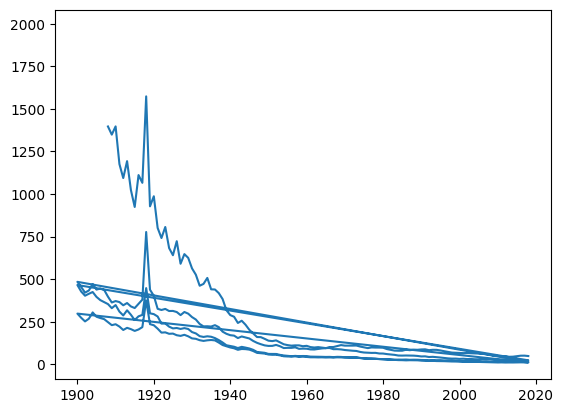

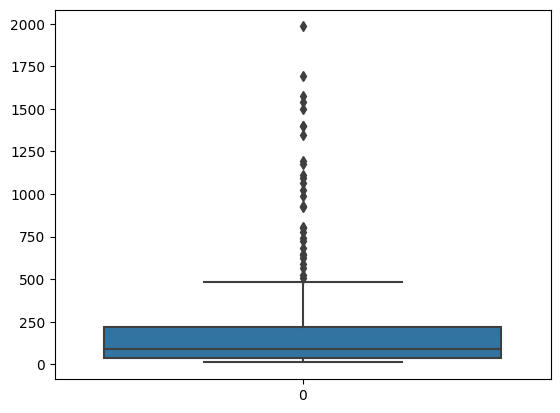

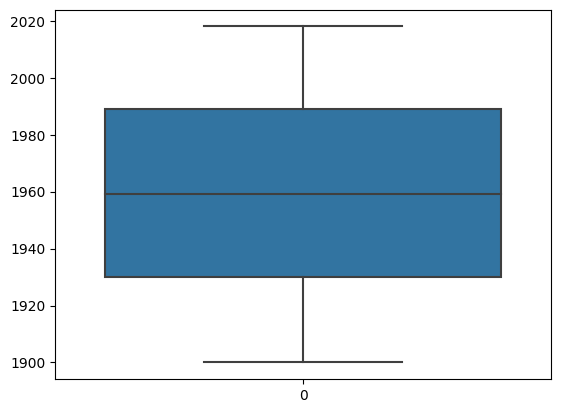

In [39]:
plt.plot(df['Year'], df['DeathRate'])
plt.show()
sns.boxplot(df['DeathRate'])
plt.show()
sns.boxplot(df['Year'])
plt.show()


In [40]:
# Deathrates above 500:
df[df['DeathRate'] > 500]

,Year,AgeGroup,DeathRate
0,1900.0,01-04 Years,1983.8
1,NaN,01-04 Years,1695.0
3,1903.0,01-04 Years,1542.1
5,1905.0,01-04 Years,1498.9
8,1908.0,01-04 Years,1396.8
9,1909.0,01-04 Years,1348.9
10,1910.0,01-04 Years,1397.3
11,1911.0,01-04 Years,1176.0
12,1912.0,01-04 Years,1094.1
13,1913.0,01-04 Years,1193.4


In [41]:
# Sort the above rows in decreasing order of DeathRate.
df[df['DeathRate'] > 500].sort_values(by = 'DeathRate', ascending = False)

,Year,AgeGroup,DeathRate
0,1900.0,01-04 Years,1983.8
1,NaN,01-04 Years,1695.0
18,1918.0,01-04 Years,1573.5
3,1903.0,01-04 Years,1542.1
5,1905.0,01-04 Years,1498.9
10,1910.0,01-04 Years,1397.3
8,1908.0,01-04 Years,1396.8
9,1909.0,01-04 Years,1348.9
13,1913.0,01-04 Years,1193.4
11,1911.0,01-04 Years,1176.0


In [42]:
df[df['DeathRate'] > 500].sort_values(by = 'Year')

,Year,AgeGroup,DeathRate
0,1900.0,01-04 Years,1983.8
3,1903.0,01-04 Years,1542.1
5,1905.0,01-04 Years,1498.9
8,1908.0,01-04 Years,1396.8
9,1909.0,01-04 Years,1348.9
10,1910.0,01-04 Years,1397.3
11,1911.0,01-04 Years,1176.0
12,1912.0,01-04 Years,1094.1
13,1913.0,01-04 Years,1193.4
14,1914.0,01-04 Years,1024.2


In [ ]:
plt.plot(df[df['DeathRate'] > 500].sort_values(by = 'Year')['Year'], df[df['DeathRate'] > 500].sort_values(by = 'Year')['DeathRate'])

In [ ]:
# Display those rows for the ageGroup of 15-19 years.
df[df['AgeGroup'] == '15-19 Years'].sort_values(by = 'Year')

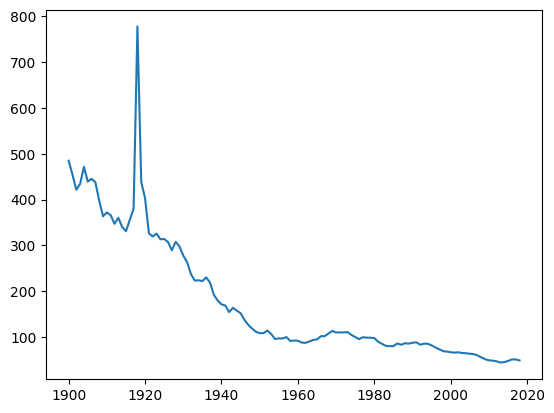

In [45]:
plt.plot(df[df['AgeGroup'] == '15-19 Years'].sort_values(by = 'Year')['Year'], df[df['AgeGroup'] == '15-19 Years'].sort_values(by = 'Year')['DeathRate'])

In [44]:
# Working on the AgeGroup - 15-19 Years.
teen_df = df[df['AgeGroup'] == '15-19 Years'].sort_values(by = 'Year')
teen_df

,Year,AgeGroup,DeathRate
357,1900.0,15-19 Years,484.8
358,1901.0,15-19 Years,454.4
359,1902.0,15-19 Years,421.5
360,1903.0,15-19 Years,434.1
361,1904.0,15-19 Years,471.4
...,...,...,...
471,2014.0,15-19 Years,45.5
472,2015.0,15-19 Years,48.3
473,2016.0,15-19 Years,51.2
474,2017.0,15-19 Years,51.5


In [43]:
teen_df.describe()

NameError: name 'teen_df' is not defined

In [ ]:
teen_df[teen_df['DeathRate'] > 500]

<Axes: xlabel='Year'>

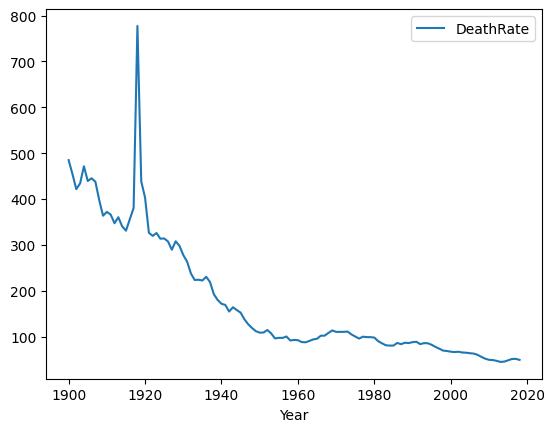

In [46]:
teen_df.plot(x = 'Year', y = 'DeathRate')

# How to fix outliers:

In [47]:
# Using mean value, we are going to fix the outlier.
teen_df['DeathRate'].mean()

177.3747899159664

In [48]:
# Replacing the mean value with the outlier.
print(teen_df[teen_df['DeathRate'] > 500]) # Before.
#teen_df[teen_df['DeathRate'] > 500]['DeathRate'] = teen_df['DeathRate'].mean() # Should work but not correct syntax.
teen_df.loc[teen_df['DeathRate'] > 500,'DeathRate'] = teen_df['DeathRate'].mean()
teen_df[teen_df['DeathRate'] > 500] # After.

       Year     AgeGroup  DeathRate
375  1918.0  15-19 Years      777.4


,Year,AgeGroup,DeathRate


<Axes: xlabel='Year'>

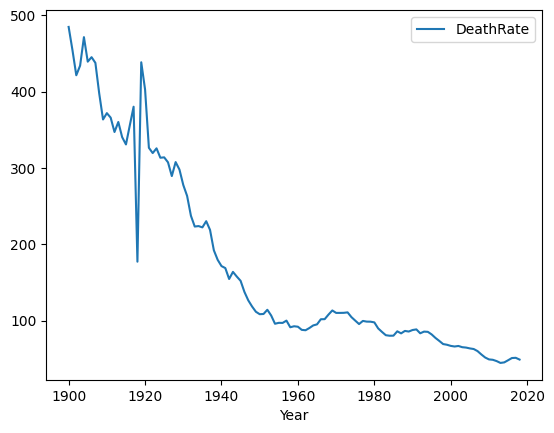

In [49]:
teen_df.plot(x = 'Year', y = 'DeathRate')